# AI4QC-2 Sentinel-2 L1C (JP2) — Step-by-step debug notebook
This notebook mirrors the `s2_l1c_data.py` pipeline, but runs interactively and plots intermediate steps (as James suggested).

In [18]:
IN_BUCKET = "sentinel-s2-l1c"

TILE = "30UXC"
START_DATE = "2015-06-01"
END_DATE = "2025-12-31"
MODE = "ALL12_FLOAT"

OUT_DIM = 128
QUANTIFICATION_VALUE = 10000.0
COVERAGE_THRESHOLD = 0.01

PID_DTYPE_LEN = 128
BATCH_SIZE = 128
USE_BATCH_WRITES = True

AWS_PROFILE = "source-keys"
AWS_REGION = "eu-central-1"

S3_BUCKET = "ai4qc2-high-compute-sentinel-zarr"
S3_PREFIX_BASE = "zarr-runs"
UPLOAD_TO_S3 = True
DELETE_LOCAL_AFTER_UPLOAD = False

S3_STORAGE_PRICE_PER_GB_MONTH = 0.023
S3_PUT_PRICE_PER_1000 = 0.005

COVERAGE_BAND = "B01"
MIN_VALID_FRACTION = 0.80

In [19]:
import os
import time

NOTEBOOK_START_TIME = time.time()

ZARR_NAME = f"s2_l1c_tile_{TILE}_{START_DATE}_to_{END_DATE}_{MODE}.zarr"
OUTPUT_DIR = f"outputs/{TILE}"
local_time_zarr = os.path.join(OUTPUT_DIR, ZARR_NAME)

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [20]:
BANDS_ALL12 = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
BANDS_RGB   = ["B04","B03","B02"]

if MODE == "ALL12_FLOAT":
    BANDS = BANDS_ALL12
elif MODE in ("RGB_FLOAT", "RGB_UINT16"):
    BANDS = BANDS_RGB
else:
    raise ValueError(f"Unknown MODE={MODE}")

## 1) Imports

In [21]:
from __future__ import annotations

import os
import re
import json
# import shutil
# import tempfile
import datetime as dt
from typing import Dict, List, Optional, Tuple

import boto3
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import Affine
# from rasterio.warp import reproject
import xarray as xr
# from PIL import Image

# import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor

from rasterio.session import AWSSession
import atexit
import shutil
import tempfile
import time
from dataclasses import dataclass
from pystac_client import Client

import threading
from rasterio.io import MemoryFile

import io
from boto3.s3.transfer import TransferConfig

MAX_WORKERS = max(1, (os.cpu_count() or 8) - 1)


In [22]:
def log_failure(log_path: str, pid: str, stage: str, err: Exception):
    rec = {
        "product_id": pid,
        "stage": stage,
        "error": repr(err),
        "ts_utc": dt.datetime.now(dt.timezone.utc).isoformat().replace("+00:00", "Z"),
    }
    with open(log_path, "a") as f:
        f.write(json.dumps(rec) + "\n")


## 2) Helpers (same as script)

In [23]:
STAC_API_URL = "https://earth-search.aws.element84.com/v1"
STAC_COLLECTION = "sentinel-2-l1c"

ASSET_KEY_FOR_BAND: Dict[str, str] = {
    "B01": "coastal",
    "B02": "blue",
    "B03": "green",
    "B04": "red",
    "B05": "rededge1",
    "B06": "rededge2",
    "B07": "rededge3",
    "B08": "nir",
    "B8A": "nir08",
    "B09": "nir09",
    "B11": "swir16",
    "B12": "swir22",
}

def parse_tile(tile: str) -> Tuple[int, str, str]:
    tile = tile.strip().upper()
    return int(tile[:2]), tile[2], tile[3:]

def normalize_href(href: str) -> str:
    if href.startswith("s3://sentinel-s2-l2a/"):      ##important to discuss, need to know if need this or not, because L2A products are in a different bucket and have different structure. If we want to use L2A products, we need to change the bucket and the structure accordingly.
        return "s3://sentinel-s2-l1c/" + href[len("s3://sentinel-s2-l2a/"):]
    return href

@dataclass(frozen=True)
class S2Task:
    system_index: str
    datetime_utc: str
    band_hrefs: Dict[str, str]
    coverage_href: str

def discover_tasks(tile: str, start_date: str, end_date: str) -> List[S2Task]:
    utm, lat_band, grid_square = parse_tile(tile)
    client = Client.open(STAC_API_URL)

    search = client.search(
        collections=[STAC_COLLECTION],
        datetime=f"{start_date}/{end_date}",
        query={
            "mgrs:utm_zone": {"eq": utm},
            "mgrs:latitude_band": {"eq": lat_band},
            "mgrs:grid_square": {"eq": grid_square},
        },
    )

    items = list(search.get_items())
    items.sort(key=lambda it: (it.datetime, it.id))

    tasks: List[S2Task] = []
    for it in items:
        hrefs = {}
        for band in BANDS:
            hrefs[band] = normalize_href(it.assets[ASSET_KEY_FOR_BAND[band]].href)

        coverage_href = normalize_href(it.assets[ASSET_KEY_FOR_BAND["B01"]].href)

        tasks.append(
            S2Task(
                system_index=it.id,
                datetime_utc=it.datetime.replace(tzinfo=dt.timezone.utc).isoformat().replace("+00:00", "Z"),
                band_hrefs=hrefs,
                coverage_href=coverage_href,
            )
        )

    return tasks

_TLS = threading.local()

def get_thread_s3_client():
    if not hasattr(_TLS, "s3"):
        session = (
            boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION)
            if AWS_PROFILE
            else boto3.Session(region_name=AWS_REGION)
        )
        _TLS.s3 = session.client("s3")
    return _TLS.s3

def parse_s3_uri(uri: str) -> Tuple[str, str]:
    if not uri.startswith("s3://"):
        raise ValueError(f"Not an s3:// URI: {uri}")
    parts = uri[5:].split("/", 1)
    bucket = parts[0]
    key = parts[1] if len(parts) > 1 else ""
    return bucket, key
    

In [24]:
def content_fraction_from_band_uri(
    jp2_uri: str,
    threshold: float = 0.001,
    out_dim: int = 64,
    retries: int = 3,
    delay: float = 1.0,
) -> float:
    bucket, key = parse_s3_uri(jp2_uri)
    last_err = None

    for attempt in range(retries):
        try:
            s3 = get_thread_s3_client()
            obj = s3.get_object(Bucket=bucket, Key=key, RequestPayer="requester")
            body = obj["Body"].read()

            with MemoryFile(body) as memfile:
                with memfile.open() as src:
                    arr = src.read(
                        1,
                        out_shape=(out_dim, out_dim),
                        resampling=Resampling.average,
                    ).astype(np.float32)

            arr = arr / float(QUANTIFICATION_VALUE)

            # fraction of pixels that contain meaningful signal
            frac = float((arr > threshold).mean())
            return frac

        except Exception as e:
            last_err = e
            if attempt < retries - 1:
                time.sleep(delay)

    raise last_err

In [25]:
tasks = discover_tasks(TILE, START_DATE, END_DATE)

print(f"Discovered tasks: {len(tasks)}")
if not tasks:
    raise RuntimeError("No STAC items found for the requested tile/date range.")

print(tasks[0])

Discovered tasks: 2116
S2Task(system_index='S2A_30UXC_20161103_0_L1C', datetime_utc='2016-11-03T11:12:24.460000Z', band_hrefs={'B01': 's3://sentinel-s2-l1c/tiles/30/U/XC/2016/11/3/0/B01.jp2', 'B02': 's3://sentinel-s2-l1c/tiles/30/U/XC/2016/11/3/0/B02.jp2', 'B03': 's3://sentinel-s2-l1c/tiles/30/U/XC/2016/11/3/0/B03.jp2', 'B04': 's3://sentinel-s2-l1c/tiles/30/U/XC/2016/11/3/0/B04.jp2', 'B05': 's3://sentinel-s2-l1c/tiles/30/U/XC/2016/11/3/0/B05.jp2', 'B06': 's3://sentinel-s2-l1c/tiles/30/U/XC/2016/11/3/0/B06.jp2', 'B07': 's3://sentinel-s2-l1c/tiles/30/U/XC/2016/11/3/0/B07.jp2', 'B08': 's3://sentinel-s2-l1c/tiles/30/U/XC/2016/11/3/0/B08.jp2', 'B8A': 's3://sentinel-s2-l1c/tiles/30/U/XC/2016/11/3/0/B8A.jp2', 'B09': 's3://sentinel-s2-l1c/tiles/30/U/XC/2016/11/3/0/B09.jp2', 'B11': 's3://sentinel-s2-l1c/tiles/30/U/XC/2016/11/3/0/B11.jp2', 'B12': 's3://sentinel-s2-l1c/tiles/30/U/XC/2016/11/3/0/B12.jp2'}, coverage_href='s3://sentinel-s2-l1c/tiles/30/U/XC/2016/11/3/0/B01.jp2')


## 6) Build RGB quicklook from the cube (B04/B03/B02)
This reproduces your `write_quicklook_b432_rgba` logic, but displays inline.

In [26]:
def read_band_out_reflectance_mem(jp2_uri: str, retries: int = 3, delay: float = 1.0) -> np.ndarray:
    bucket, key = parse_s3_uri(jp2_uri)
    last_err = None

    for attempt in range(retries):
        try:
            s3 = get_thread_s3_client()
            obj = s3.get_object(Bucket=bucket, Key=key, RequestPayer="requester")
            body = obj["Body"].read()

            with MemoryFile(body) as memfile:
                with memfile.open() as src:
                    dn_ds = src.read(
                        1,
                        out_shape=(OUT_DIM, OUT_DIM),
                        resampling=Resampling.average,
                    ).astype(np.float32)

            return dn_ds / float(QUANTIFICATION_VALUE)

        except Exception as e:
            last_err = e
            if attempt < retries - 1:
                time.sleep(delay)

    raise last_err

Build the cube

In [27]:
sample = tasks[:20]

fractions = []
for task in sample:
    frac = content_fraction_from_band_uri(task.band_hrefs["B02"], threshold=0.001, out_dim=64)
    fractions.append((task.system_index, frac))

for pid, frac in fractions:
    print(pid, "->", frac)

S2A_30UXC_20161103_0_L1C -> 1.0
S2A_30UXC_20161106_0_L1C -> 0.3759765625
S2A_30UXC_20161110_0_L1C -> 0.293212890625
S2A_30UXC_20161113_1_L1C -> 0.9970703125
S2A_30UXC_20161113_0_L1C -> 0.11181640625
S2A_30UXC_20161116_0_L1C -> 0.373291015625
S2A_30UXC_20161120_0_L1C -> 0.297119140625
S2A_30UXC_20161123_0_L1C -> 1.0
S2A_30UXC_20161126_0_L1C -> 0.37158203125
S2A_30UXC_20161130_0_L1C -> 0.296875
S2A_30UXC_20161203_0_L1C -> 1.0
S2A_30UXC_20161206_0_L1C -> 0.36962890625
S2A_30UXC_20161210_0_L1C -> 0.2978515625
S2A_30UXC_20161213_0_L1C -> 1.0
S2A_30UXC_20161216_1_L1C -> 0.000732421875
S2A_30UXC_20161216_0_L1C -> 0.370849609375
S2A_30UXC_20161220_0_L1C -> 0.286376953125
S2A_30UXC_20161223_0_L1C -> 0.7646484375
S2A_30UXC_20161223_1_L1C -> 0.43603515625
S2A_30UXC_20161226_0_L1C -> 0.3837890625


Parallelise the workers

In [28]:
MIN_CONTENT_FRACTION = 0.80
CONTENT_BAND = "B01"
CONTENT_THRESHOLD = 0.001

def read_band_and_content_fraction(
    jp2_uri: str,
    threshold: float = 0.001,
    out_dim: int = 64,
    retries: int = 3,
    delay: float = 1.0,
):
    bucket, key = parse_s3_uri(jp2_uri)
    last_err = None

    for attempt in range(retries):
        try:
            s3 = get_thread_s3_client()
            obj = s3.get_object(Bucket=bucket, Key=key, RequestPayer="requester")
            body = obj["Body"].read()

            with MemoryFile(body) as memfile:
                with memfile.open() as src:
                    # full-resolution-for-output read
                    dn_ds = src.read(
                        1,
                        out_shape=(OUT_DIM, OUT_DIM),
                        resampling=Resampling.average,
                    ).astype(np.float32)

                    # cheap content check on a smaller preview
                    preview = src.read(
                        1,
                        out_shape=(out_dim, out_dim),
                        resampling=Resampling.average,
                    ).astype(np.float32)

            arr = dn_ds / float(QUANTIFICATION_VALUE)
            preview = preview / float(QUANTIFICATION_VALUE)
            frac = float((preview > threshold).mean())

            return arr, frac

        except Exception as e:
            last_err = e
            if attempt < retries - 1:
                time.sleep(delay)

    raise last_err


def process_one_task(task: S2Task) -> tuple[str, np.datetime64, np.ndarray, Optional[str]]:
    try:
        t = np.datetime64(task.datetime_utc.replace("Z", ""))

        # read coverage band once, and reuse it
        content_arr, content_fraction = read_band_and_content_fraction(
            task.band_hrefs[CONTENT_BAND],
            threshold=CONTENT_THRESHOLD,
            out_dim=64,
        )

        if content_fraction < MIN_CONTENT_FRACTION:
            return (
                task.system_index,
                np.datetime64("NaT"),
                np.empty((0,), dtype=np.float32),
                f"SKIP_LOW_CONTENT:{content_fraction:.3f}",
            )

        arrays = []
        for band in BANDS:
            if band == CONTENT_BAND:
                arr = content_arr
            else:
                arr = read_band_out_reflectance_mem(task.band_hrefs[band])
            arrays.append(arr)

        cube_i = np.stack(arrays, axis=-1)
        return task.system_index, t, cube_i, None

    except Exception as e:
        return task.system_index, np.datetime64("NaT"), np.empty((0,), dtype=np.float32), repr(e)

Zarr stacking helper methods

In [29]:
def load_existing_store_state(local_zarr):
    """Return (wrote, existing_set, pid_dtype_len_from_store_or_None, time_chunk_or_None, ds_existing_or_None)."""
    if not os.path.exists(local_zarr):
        return False, set(), None, None, None

    try:
        ds_existing = xr.open_zarr(local_zarr, consolidated=False)
        store_u = ds_existing["system_index"].dtype.itemsize // 4  # U len
        existing = set(map(str, ds_existing["system_index"].values.tolist()))
        time_chunk = int(ds_existing["reflectance"].chunks[0][0])
        return True, existing, store_u, time_chunk, ds_existing
    except Exception as e:
        print(f"[WARN] Could not open existing Zarr for resume: {e!r}")
        return False, set(), None, None, None

def compute_georef_from_task(task: S2Task):
    boto_session = (
        boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION)
        if AWS_PROFILE
        else boto3.Session(region_name=AWS_REGION)
    )
    aws_sess = AWSSession(boto_session, requester_pays=True)

    with rasterio.Env(
        aws_sess,
        AWS_REGION=AWS_REGION,
        AWS_REQUEST_PAYER="requester",
        GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
        CPL_VSIL_CURL_ALLOWED_EXTENSIONS=".jp2,.xml,.json,.JP2",
        PROJ_NETWORK="OFF",
    ):
        href = task.band_hrefs.get("B02") or next(iter(task.band_hrefs.values()))
        with rasterio.open(href) as src:
            crs_wkt = src.crs.to_wkt()
            transform = src.transform
            dst_transform = transform * Affine.scale(src.width / OUT_DIM, src.height / OUT_DIM)

    cols = np.arange(OUT_DIM)
    rows = np.arange(OUT_DIM)
    x_easting, _ = dst_transform * (cols + 0.5, np.zeros_like(cols) + 0.5)
    _, y_northing = dst_transform * (np.zeros_like(rows) + 0.5, rows + 0.5)

    return (
        np.asarray(x_easting, dtype=np.float64),
        np.asarray(y_northing, dtype=np.float64),
        crs_wkt,
        dst_transform,
    )

def make_ds_block(pids, times, cubes, band_names, out_dim, pid_dtype_len, x_easting, y_northing, time_chunk):
    block_f32 = np.stack(cubes, axis=0).astype(np.float32)  # reflectance float32

    if MODE == "RGB_UINT16":
        # Store reflectance scaled to uint16 (0..1 mapped to 0..10000)
        STORE_SCALE = 10000.0
        block_u16 = np.rint(np.clip(block_f32, 0.0, 1.0) * STORE_SCALE).astype(np.uint16)
        out_data = block_u16
    else:
        out_data = block_f32

    pid_u = np.array(pids, dtype=f"U{pid_dtype_len}")
    t_ns = np.array(times, dtype="datetime64[ns]")

    ds = xr.Dataset(
        data_vars={"reflectance": (["time", "y", "x", "band"], out_data)},
        coords={
            "time": ("time", t_ns),
            "y": ("y", y_northing),
            "x": ("x", x_easting),
            "band": np.arange(len(band_names)),
            "band_name": ("band", band_names),
            "system_index": ("time", pid_u),
        },
    )

    ds = ds.chunk({"time": min(time_chunk, out_data.shape[0]), "y": out_dim, "x": out_dim, "band": len(band_names)})

    ds["x"].attrs.update({"standard_name": "projection_x_coordinate", "units": "m"})
    ds["y"].attrs.update({"standard_name": "projection_y_coordinate", "units": "m"})
    ds["time"].encoding = {
        "units": "nanoseconds since 1970-01-01 00:00:00",
        "calendar": "proleptic_gregorian",
        "dtype": "int64",
    }
    if MODE == "RGB_UINT16":
        ds["reflectance"].attrs.update({
            "stored_as": "uint16_scaled",
            "packing_scale_factor": 1.0 / STORE_SCALE,
            "packing_add_offset": 0.0,
            "packing_note": "Recover reflectance_float = reflectance_uint16 * packing_scale_factor + packing_add_offset",
        })
    return ds


def finalize_store_attrs(local_zarr, crs_wkt=None, dst_transform=None):
    ds_final = xr.open_zarr(local_zarr, consolidated=False, decode_times=False)
    tvals = ds_final["time"].values.astype("int64")

    attrs = dict(ds_final.attrs)
    if tvals.size:
        attrs.update({"time_start_ns": int(tvals.min()), "time_end_ns": int(tvals.max()), "num_timesteps": int(tvals.size)})
    else:
        attrs.update({"num_timesteps": 0})

    if (crs_wkt is not None) and (dst_transform is not None):
        attrs.update({
            "crs_wkt": crs_wkt,
            "dst_transform_gdal": tuple(dst_transform.to_gdal()),
            "dst_transform_affine": [dst_transform.a, dst_transform.b, dst_transform.c,
                                     dst_transform.d, dst_transform.e, dst_transform.f],
        })

    ds_final.assign_attrs(attrs).to_zarr(local_zarr, mode="a", consolidated=True)

In [30]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 7) Optional: write Zarr locally (no upload)
This writes the same dataset structure your script writes, but to a local folder so you can open and inspect quickly.

In [31]:
# (A) DEBUG single-time Zarr
# local_debug_zarr = write_debug_single_time_zarr(
#     BANDS, band_local_paths, product_id, SAFE_PREFIX, tile,
#     OUT_DIM, QUANTIFICATION_VALUE, COVERAGE_THRESHOLD, IN_BUCKET, tmp
# )
# local_debug_zarr

t_start = time.time()
n_done = 0

# (B) FULL time-stacked cube
BUILD_TIME_STACK = True
if not BUILD_TIME_STACK:
    raise SystemExit("Time stack build disabled.")

# local_time_zarr = os.path.join(tmp, ZARR_NAME)
local_time_zarr = os.path.join(OUTPUT_DIR, ZARR_NAME)

wrote, existing, store_u, time_chunk_existing, _ = load_existing_store_state(local_time_zarr)
pid_dtype_len = store_u if store_u is not None else PID_DTYPE_LEN

TIME_CHUNK = time_chunk_existing if (time_chunk_existing is not None) else (BATCH_SIZE if USE_BATCH_WRITES else 1)
print("Resume:", wrote, "| existing:", len(existing), "| pid dtype:", pid_dtype_len, "| time_chunk:", TIME_CHUNK)

tasks_todo = [t for t in tasks if t.system_index not in existing]
print("tasks total:", len(tasks), "| todo:", len(tasks_todo))

if not tasks_todo:
    print("Nothing new to process (all in existing).")
    raise SystemExit(local_time_zarr)

x_easting, y_northing, crs_wkt, dst_transform = compute_georef_from_task(tasks_todo[0])

base_attrs = {
    "mgrs_tile": TILE,
    "processing": "...",
    "quantification_value_divisor": float(QUANTIFICATION_VALUE),
    "coverage_threshold": float(COVERAGE_THRESHOLD),
    "out_dim": int(OUT_DIM),
    "source_bucket": IN_BUCKET,
}
if (crs_wkt is not None) and (dst_transform is not None):
    base_attrs.update({"crs_wkt": crs_wkt, "dst_transform_gdal": tuple(dst_transform.to_gdal())})

print(f"Submitting {len(tasks_todo)} timesteps to {MAX_WORKERS} workers...")

# failure_log = os.path.join(tmp, "failures.jsonl")
failure_log = os.path.join(OUTPUT_DIR, "failures.jsonl")
batch_pids, batch_times, batch_cubes = [], [], []

skipped_low_content = 0

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
    for j, (pid, t, cube_i, err) in enumerate(ex.map(process_one_task, tasks_todo), start=1):
        try:
            if err is not None:
                if str(err).startswith("SKIP_LOW_CONTENT:"):
                    skipped_low_content += 1
                    if skipped_low_content % 50 == 0:
                        print(f"Skipped low-content scenes: {skipped_low_content}")
                    continue

                log_failure(failure_log, pid, stage="process_one_task", err=Exception(err))
                print(f"[WARN] failed {pid}: {err}")
                continue

            if pid in existing or pid in batch_pids:
                continue
            if len(pid) > pid_dtype_len:
                raise ValueError(f"pid too long for store dtype U{pid_dtype_len}: {pid} (len={len(pid)})")

            batch_pids.append(pid)
            batch_times.append(t)
            batch_cubes.append(cube_i)

            should_flush = (not USE_BATCH_WRITES) or (len(batch_pids) >= BATCH_SIZE)
            if should_flush:
                ds_block = make_ds_block(
                    batch_pids, batch_times, batch_cubes,
                    BANDS, OUT_DIM, pid_dtype_len,
                    x_easting, y_northing, TIME_CHUNK
                )

                if not wrote:
                    ds_block.assign_attrs(base_attrs).to_zarr(local_time_zarr, mode="w", consolidated=True)
                    wrote = True
                else:
                    ds_block.to_zarr(local_time_zarr, mode="a", append_dim="time", consolidated=False)

                flushed = len(batch_pids)
                existing.update(batch_pids)
                batch_pids, batch_times, batch_cubes = [], [], []

                n_done += flushed
                elapsed = time.time() - t_start
                rate = n_done / (elapsed / 60.0)
                print(f"Wrote {n_done} timesteps in {elapsed/60:.1f} min => {rate:.2f} timesteps/min")

            if j % 25 == 0:
                # elapsed = time.time() - t_start
                # rate = n_done / (elapsed / 60.0) if elapsed > 0 else 0.0
                # print(
                #     f"Processed {j}/{len(tasks_todo)} timesteps | "
                #     f"kept={n_done} | skipped={skipped_low_content} | "
                #     f"rate={rate:.2f} timesteps/min"
                # )
                elapsed = time.time() - t_start
                kept_rate = n_done / (elapsed / 60.0) if elapsed > 0 else 0.0
                examined_rate = j / (elapsed / 60.0) if elapsed > 0 else 0.0

                print(
                    f"Processed {j}/{len(tasks_todo)} | "
                    f"kept={n_done} | skipped={skipped_low_content} | "
                    f"kept_rate={kept_rate:.2f}/min | examined_rate={examined_rate:.2f}/min"
                )

        except Exception as e:
            log_failure(failure_log, pid if "pid" in locals() else "UNKNOWN", stage="parallel_bulk", err=e)
            print(f"[WARN] parallel timestep failed: {e!r}")

if batch_pids:
    ds_block = make_ds_block(
        batch_pids, batch_times, batch_cubes,
        BANDS, OUT_DIM, pid_dtype_len,
        x_easting, y_northing, TIME_CHUNK
    )
    if not wrote:
        ds_block.assign_attrs(base_attrs).to_zarr(local_time_zarr, mode="w", consolidated=True)
        wrote = True
    else:
        ds_block.to_zarr(local_time_zarr, mode="a", append_dim="time", consolidated=False)

    flushed = len(batch_pids)
    existing.update(batch_pids)
    n_done += flushed

    elapsed = time.time() - t_start
    rate = n_done / (elapsed / 60.0)
    print(f"Wrote {n_done} timesteps in {elapsed/60:.1f} min => {rate:.2f} timesteps/min")

print(f"Total low-content scenes skipped: {skipped_low_content}")
print(f"Total kept/written scenes: {n_done}")

Resume: False | existing: 0 | pid dtype: 128 | time_chunk: 128
tasks total: 2116 | todo: 2116
Submitting 2116 timesteps to 7 workers...
Processed 50/2116 | kept=0 | skipped=34 | kept_rate=0.00/min | examined_rate=100.83/min
Skipped low-content scenes: 50
Processed 100/2116 | kept=0 | skipped=72 | kept_rate=0.00/min | examined_rate=126.01/min
Skipped low-content scenes: 100
Processed 150/2116 | kept=0 | skipped=106 | kept_rate=0.00/min | examined_rate=128.06/min
Skipped low-content scenes: 150
Processed 275/2116 | kept=0 | skipped=188 | kept_rate=0.00/min | examined_rate=115.73/min
Skipped low-content scenes: 200
Skipped low-content scenes: 250
Processed 375/2116 | kept=0 | skipped=255 | kept_rate=0.00/min | examined_rate=118.36/min


/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=128, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=3, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr 

Wrote 128 timesteps in 3.4 min => 37.76 timesteps/min
Processed 425/2116 | kept=128 | skipped=288 | kept_rate=35.71/min | examined_rate=118.56/min
Skipped low-content scenes: 300
Processed 475/2116 | kept=128 | skipped=322 | kept_rate=32.07/min | examined_rate=118.99/min
Processed 500/2116 | kept=128 | skipped=338 | kept_rate=30.32/min | examined_rate=118.42/min
Skipped low-content scenes: 350
Processed 550/2116 | kept=128 | skipped=373 | kept_rate=28.31/min | examined_rate=121.64/min
Processed 575/2116 | kept=128 | skipped=389 | kept_rate=27.03/min | examined_rate=121.41/min
Skipped low-content scenes: 400
Skipped low-content scenes: 450
Skipped low-content scenes: 500


/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=128, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


Wrote 256 timesteps in 6.4 min => 40.20 timesteps/min
Skipped low-content scenes: 550
Processed 875/2116 | kept=256 | skipped=589 | kept_rate=36.10/min | examined_rate=123.39/min
Skipped low-content scenes: 600
Processed 900/2116 | kept=256 | skipped=605 | kept_rate=34.93/min | examined_rate=122.80/min
Skipped low-content scenes: 650
Processed 975/2116 | kept=256 | skipped=656 | kept_rate=32.49/min | examined_rate=123.75/min
Processed 1025/2116 | kept=256 | skipped=690 | kept_rate=30.99/min | examined_rate=124.08/min
Skipped low-content scenes: 700
Processed 1050/2116 | kept=256 | skipped=707 | kept_rate=30.20/min | examined_rate=123.88/min
Processed 1075/2116 | kept=256 | skipped=724 | kept_rate=29.32/min | examined_rate=123.13/min
Processed 1100/2116 | kept=256 | skipped=741 | kept_rate=28.93/min | examined_rate=124.32/min
Skipped low-content scenes: 750


...

Wrote 512 timesteps in 12.8 min => 39.91 timesteps/min
Processed 1625/2116 | kept=512 | skipped=1097 | kept_rate=38.55/min | examined_rate=122.34/min
Skipped low-content scenes: 1100
Skipped low-content scenes: 1150
Processed 1725/2116 | kept=512 | skipped=1164 | kept_rate=36.24/min | examined_rate=122.09/min
Processed 1750/2116 | kept=512 | skipped=1181 | kept_rate=35.59/min | examined_rate=121.66/min
Skipped low-content scenes: 1200
Skipped low-content scenes: 1250
Processed 1875/2116 | kept=512 | skipped=1265 | kept_rate=33.25/min | examined_rate=121.76/min
Processed 1925/2116 | kept=512 | skipped=1299 | kept_rate=32.31/min | examined_rate=121.49/min
Skipped low-content scenes: 1300


/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=128, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


Wrote 640 timesteps in 16.2 min => 39.58 timesteps/min
Processed 1975/2116 | kept=640 | skipped=1333 | kept_rate=39.49/min | examined_rate=121.88/min
Skipped low-content scenes: 1350
Skipped low-content scenes: 1400


/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=128, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


Wrote 686 timesteps in 17.2 min => 39.78 timesteps/min
Total low-content scenes skipped: 1430
Total kept/written scenes: 686


## 8) Cleanup
Delete the temporary download folder when you're done.

Quick structural sanity checks

In [1]:
import xarray as xr
import numpy as np

# z = os.path.join(OUTPUT_DIR, ZARR_NAME)
z = "outputs/30UXC/s2_l1c_tile_30UXC_2015-06-01_to_2025-12-31_ALL12_FLOAT.zarr"
ds = xr.open_zarr(z, consolidated=False)

print(ds)
print("dims:", ds.dims)
print("reflectance dtype:", ds["reflectance"].dtype)
print("reflectance shape:", ds["reflectance"].shape)
print("band_name:", ds["band_name"].values.tolist())
print("time count:", ds.dims["time"])
print("time min/max:", ds["time"].values.min(), ds["time"].values.max())
print("unique system_index count:", len(np.unique(ds["system_index"].values)))


<xarray.Dataset> Size: 540MB
Dimensions:       (time: 686, y: 128, x: 128, band: 12)
Coordinates:
  * time          (time) datetime64[ns] 5kB 2016-11-03T11:12:24.460000 ... 20...
  * y             (y) float64 1kB 5.8e+06 5.799e+06 ... 5.692e+06 5.691e+06
  * x             (x) float64 1kB 6.004e+05 6.013e+05 ... 7.085e+05 7.094e+05
  * band          (band) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
    band_name     (band) <U3 144B dask.array<chunksize=(12,), meta=np.ndarray>
    system_index  (time) <U128 351kB dask.array<chunksize=(128,), meta=np.ndarray>
Data variables:
    reflectance   (time, y, x, band) float32 539MB dask.array<chunksize=(128, 128, 128, 12), meta=np.ndarray>
dims: FrozenMappingWarningOnValuesAccess({'time': 686, 'y': 128, 'x': 128, 'band': 12})
reflectance dtype: float32
reflectance shape: (686, 128, 128, 12)
band_name: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12']
time count: 686
time min/max: 2016-11-03T11:12:24.460000000 2025-12-

/tmp/ipykernel_2010/1263422150.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("time count:", ds.dims["time"])


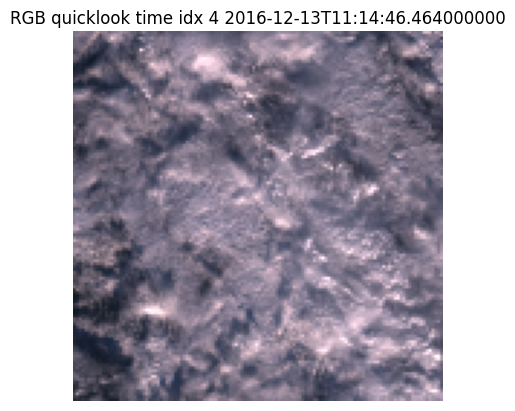

In [4]:
import matplotlib.pyplot as plt

tidx = 4
B04 = int(np.where(ds["band_name"].values == "B04")[0][0])
B03 = int(np.where(ds["band_name"].values == "B03")[0][0])
B02 = int(np.where(ds["band_name"].values == "B02")[0][0])

rgb = np.stack([
    ds["reflectance"].isel(time=tidx, band=B04).values,
    ds["reflectance"].isel(time=tidx, band=B03).values,
    ds["reflectance"].isel(time=tidx, band=B02).values,
], axis=-1)

plt.figure()
plt.title(f"RGB quicklook time idx {tidx} {ds['time'].values[tidx]}")
plt.imshow(np.clip(rgb, 0, 1))
plt.axis("off")
plt.show()


In [34]:
# import os
# import json
# import time
# import shutil
# import subprocess
# from pathlib import Path

# # ---- total runtime ----
# elapsed_seconds = time.time() - NOTEBOOK_START_TIME
# elapsed_minutes = elapsed_seconds / 60.0

# # ---- local zarr path ----
# zarr_path = Path(local_time_zarr)

# # ---- measure zarr size ----
# total_bytes = 0
# file_count = 0

# for p in zarr_path.rglob("*"):
#     if p.is_file():
#         total_bytes += p.stat().st_size
#         file_count += 1

# size_mb = total_bytes / (1024**2)
# size_gb = total_bytes / (1024**3)

# print(f"Zarr size: {size_mb:.2f} MB ({size_gb:.4f} GB)")
# print(f"File count: {file_count}")

# # ---- cost calculation using your assumptions ----
# monthly_storage_cost = size_gb * S3_STORAGE_PRICE_PER_GB_MONTH
# put_request_cost = (file_count / 1000.0) * S3_PUT_PRICE_PER_1000
# first_month_total_cost = monthly_storage_cost + put_request_cost

# print(f"Monthly storage cost: ${monthly_storage_cost:.6f}")
# print(f"PUT request cost: ${put_request_cost:.6f}")
# print(f"First month total cost: ${first_month_total_cost:.6f}")

# # ---- upload to S3 ----
# s3_uri = f"s3://{S3_BUCKET}/{S3_PREFIX_BASE}/{TILE}/{ZARR_NAME}/"

# upload_seconds = None
# upload_minutes = None
# upload_speed_mb_s = None
# upload_status = "not_requested"
# upload_error = ""

# if UPLOAD_TO_S3:
#     print(f"Uploading to {s3_uri}")
#     t0 = time.time()
#     try:
#         cmd = ["aws", "s3", "cp", local_time_zarr, s3_uri, "--recursive"]

#         if AWS_PROFILE:
#             cmd.extend(["--profile", AWS_PROFILE])

#         subprocess.run(cmd, check=True)
#         upload_seconds = time.time() - t0
#         upload_minutes = upload_seconds / 60.0
#         upload_speed_mb_s = size_mb / upload_seconds if upload_seconds > 0 else None
#         upload_status = "success"

#         print(f"Upload time: {upload_seconds:.2f} seconds")
#         print(f"Upload time: {upload_minutes:.2f} minutes")
#         print(f"Approx upload speed: {upload_speed_mb_s:.2f} MB/s")

#     except Exception as e:
#         upload_status = "failed"
#         upload_error = repr(e)
#         print(f"Upload failed: {upload_error}")

# # ---- optional local cleanup ----
# if UPLOAD_TO_S3 and upload_status == "success" and DELETE_LOCAL_AFTER_UPLOAD:
#     shutil.rmtree(local_time_zarr, ignore_errors=True)
#     print(f"Deleted local zarr: {local_time_zarr}")

# # ---- timesteps written ----
# timesteps_written = None
# if "ds" in locals():
#     try:
#         timesteps_written = int(ds.sizes["time"])
#     except Exception:
#         timesteps_written = None

# if timesteps_written is None and os.path.exists(local_time_zarr):
#     try:
#         ds_check = xr.open_zarr(local_time_zarr, consolidated=False)
#         timesteps_written = int(ds_check.sizes["time"])
#     except Exception:
#         timesteps_written = None

# # ---- save run summary for driver notebook ----
# run_summary = {
#     "tile": TILE,
#     "start_date": START_DATE,
#     "end_date": END_DATE,
#     "mode": MODE,
#     "tasks_discovered": len(tasks) if "tasks" in locals() else None,
#     "tasks_todo": len(tasks_todo) if "tasks_todo" in locals() else None,
#     "timesteps_written": timesteps_written,
#     "elapsed_seconds": round(elapsed_seconds, 2),
#     "elapsed_minutes": round(elapsed_minutes, 2),
#     "zarr_path_local": str(local_time_zarr),
#     "zarr_size_bytes": total_bytes,
#     "zarr_size_mb": round(size_mb, 2),
#     "zarr_size_gb": round(size_gb, 6),
#     "file_count": file_count,
#     "monthly_storage_cost_usd": round(monthly_storage_cost, 6),
#     "put_request_cost_usd": round(put_request_cost, 6),
#     "first_month_total_cost_usd": round(first_month_total_cost, 6),
#     "s3_uri": s3_uri,
#     "upload_status": upload_status,
#     "upload_error": upload_error,
#     "upload_seconds": round(upload_seconds, 2) if upload_seconds is not None else None,
#     "upload_minutes": round(upload_minutes, 2) if upload_minutes is not None else None,
#     "upload_speed_mb_s": round(upload_speed_mb_s, 2) if upload_speed_mb_s is not None else None,
# }

# summary_path = os.path.join(OUTPUT_DIR, "run_summary.json")
# with open(summary_path, "w") as f:
#     json.dump(run_summary, f, indent=2)

# print(f"Saved run summary to {summary_path}")
# print(f"TOTAL NOTEBOOK RUNTIME: {elapsed_minutes:.2f} minutes")

In [40]:
import numpy as np

print("sizes:", ds.sizes)
print("reflectance dtype:", ds["reflectance"].dtype)
print("reflectance shape:", ds["reflectance"].shape)
print("band_name:", ds["band_name"].values.tolist())
print("unique system_index count:", len(np.unique(ds["system_index"].values)))

# time order
time_vals = ds["time"].values
is_sorted = np.all(time_vals[:-1] <= time_vals[1:])
print("time sorted:", is_sorted)

# duplicates
pid_vals = ds["system_index"].values
print("duplicate system_index count:", len(pid_vals) - len(np.unique(pid_vals)))

sizes: Frozen({'time': 686, 'y': 128, 'x': 128, 'band': 12})
reflectance dtype: float32
reflectance shape: (686, 128, 128, 12)
band_name: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12']
unique system_index count: 686
time sorted: True
duplicate system_index count: 0


In [5]:
import numpy as np

band_names = ds["band_name"].values.tolist()
b02_idx = band_names.index("B02")

fractions = []
for i in range(ds.sizes["time"]):
    arr = ds["reflectance"].isel(time=i, band=b02_idx).values
    frac = float((arr > 0.001).mean())
    fractions.append(frac)

fractions = np.array(fractions)

print("content fraction stats for B02")
print("min   :", fractions.min())
print("p10   :", np.percentile(fractions, 10))
print("p25   :", np.percentile(fractions, 25))
print("median:", np.median(fractions))
print("p75   :", np.percentile(fractions, 75))
print("max   :", fractions.max())

print("count < 0.5 :", (fractions < 0.5).sum())
print("count < 0.6 :", (fractions < 0.6).sum())
print("count < 0.7 :", (fractions < 0.7).sum())
print("count < 0.8 :", (fractions < 0.8).sum())

content fraction stats for B02
min   : 0.807861328125
p10   : 1.0
p25   : 1.0
median: 1.0
p75   : 1.0
max   : 1.0
count < 0.5 : 0
count < 0.6 : 0
count < 0.7 : 0
count < 0.8 : 0


In [37]:
# worst_idx = np.argsort(fractions)[:5]
# for idx in worst_idx:
#     print(idx, ds["system_index"].values[idx], fractions[idx])
#     # show_rgb(ds, int(idx))

In [6]:
# import matplotlib.pyplot as plt

# plt.hist(fractions, bins=40)
# plt.xlabel("Content Fraction")
# plt.ylabel("Scene Count")
# plt.title("Content Fraction Distribution")
# plt.show()